# Setup

In [5]:
!pip install -q langchain_community --upgrade

import os
from langchain_community.chat_models import ChatOpenAI # Updated import statement
from langchain.tools import tool
from langgraph.graph import StateGraph, END
from langsmith import traceable
import graphviz
from typing import Dict, Any

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 4.2 MB/s eta 0:00:00


In [6]:
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "tool-selector-langgraph"
os.environ["LANGCHAIN_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGCHAIN_API_KEY"] = ""  # Replace this securely
os.environ["OPENAI_API_KEY"] = "sk---"

# Define Tools

In [7]:
# ---
# Define Tools
@tool
def search_web(query: str) -> str:
    """Use the web to look something up."""
    return f"[FAKE SEARCH RESULT for '{query}']"

@tool
def calculator(expression: str) -> str:
    """Do basic math operations."""
    try:
        return str(eval(expression))
    except:
        return "Error in calculation."

search_web.name = "search_web"
calculator.name = "calculator"
tools = {tool.name: tool for tool in [search_web, calculator]}

# Tool Selector Agent

In [8]:
# ---
# Tool Selector Agent
@traceable(name="ToolSelector")
def tool_selector(state):
    query = state["input"]
    llm = ChatOpenAI(temperature=0)

    SYSTEM_PROMPT = (
        "You are a routing agent. Based on the user input, respond with just one line: \n"
        "tool: <tool_name>\n"
        "Available tools: search_web, calculator"
    )

    response = llm.invoke([
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": query}
    ])

    tool_name = response.content.strip().split(":")[-1].strip()
    return {"selected_tool": tool_name, "input": query}

#  Tool Execution Node

In [15]:
# ---
#  Tool Execution Node
@traceable(name="RunSelectedTool")
def execute_tool(state):
    import re
    tool_name = state["selected_tool"]
    query = state["input"]

    if tool_name == "calculator":
        # Extract just the math expression
        matches = re.findall(r"[\d+\-*/(). ]+", query)
        query = "".join(matches).strip()

    tool_fn = tools.get(tool_name)
    if tool_fn:
        result = tool_fn.invoke(query)
        return {"result": result}
    return {"result": "Unknown tool selected."}


# Build the LangGraph

In [16]:
# ---
# Build the LangGraph
workflow = StateGraph(state_schema=Dict[str, Any])
workflow.add_node("selector", tool_selector)
workflow.add_node("tool", execute_tool)

workflow.set_entry_point("selector")
workflow.add_edge("selector", "tool")
workflow.set_finish_point("tool")

graph = workflow.compile()

# Visualize the Graph

In [17]:
# ---
# Visualize the Graph
from graphviz import Digraph
viz = Digraph()
viz.attr(rankdir="LR")
viz.node("selector", shape="box")
viz.node("tool", shape="box")
viz.node("END", shape="oval")

viz.edge("selector", "tool")
viz.edge("tool", "END")

viz.render("tool_selector_graph", format="png", cleanup=False, view=True)

'tool_selector_graph.png'

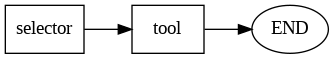

In [20]:
viz.render("react_langgraph_simple", format="png", cleanup=False, view=True)

from IPython.display import Image, display
display(Image(filename="tool_selector_graph.png"))

# Run Example

In [21]:
# ---
# Run Example
inputs = {"input": "Please calculate 9 * 6"}
output = graph.invoke(inputs)
print("\n Final Output:", output["result"])


 Final Output: 54


In [19]:
# ---
# Example Prompts
print("""
Try these prompts:
- What's the capital of Germany?
- Please calculate 3 + 5 * 2
- Tell me the weather in Tokyo
""")


Try these prompts:
- What's the capital of Germany?
- Please calculate 3 + 5 * 2
- Tell me the weather in Tokyo

